<a href="https://colab.research.google.com/github/luciestrada/Ejercicios-info2/blob/main/Proyecto2_biosenales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Consulta**

**Consultar qué índices del EEG, adicionales a los realizados en el proyecto 1 basados en
densidad espectral de potencia, mejoran la clasificación de estados en BCI. Citar las fuentes**

En el proyecto 1 utilizamos la densidad espectral de potencia (PSD) calculado con el método de Welch.

1.   **Varianza logarítmica CSP (Patrones Espaciles Comunes)**
Es una técnica de extracción de características ampliamente utilizada en problemas de clasificiación binaria, utiliza un filtrado espacial que transforma señales muticanal de EEG proyectándolas en una matriz de pesos óptimos. El funcionamiento matemático se basa en maximizar la varianza de la señal filtrada para una clase (por ejemplo la imaginación del movimiento de la mano derecha), mientras minimiza la varianza para la otra clase (mano izquierda). Una vez aplicados los filtros espaciales, se calcula la varianza de estas nuevas señales proyectadas y se le aplica una transformación logarítmica (Ramoser et al., 2000).

Para cosntruir las caracteríticas Log-Varianza, se calcula la varianza de cada señal z, se normaliza por la varianza total de todas las señales, y se aplica una transformada logarítimca.

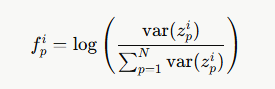

El vector de características final se construye  combinando las log-varianzas de todas las señales.


2. **Entropía de Permutación (PE)**

3. **Longitud de la Curva de la Señal (Waveform Length - WL)**

4. **Parámetros de Hjorth (dominio temporal)**

**Escoger por lo menos tres índices que se puedan implementar en Python, se pueden usar
librerías, explicar la medida y su uso en los datos del proyecto**

En el contexto de los datos del proyecto, se aplica CSP de manera binaria por pares de condiciones: MR-D vs MR-I, y IM-D vs IM-I, utilizando los 6 canales seleccionados (C3, C4, FC3, FC4, CP3, CP4). Se seleccionan los primeros y últimos 3 componentes del vector propio (m=3, es decir 6 filtros espaciales), tal como recomienda la literatura. La log-varianza de estos componentes constituye el vector de características que se almacena en el dataframe junto con las métricas del proyecto 1.

**Implementación en Python:** Se puede implementar directamente utilizando la librería especializada en neurotecnología MNE-Python (mne.decoding.CSP) en combinación con scikit-learn.

In [ ]:
from mne.decoding import CSP
import numpy as np

# Suponiendo que 'epochs_data' tiene la forma (trials, canales, muestras)
# y 'labels' contiene las etiquetas de las clases (0 o 1)
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

# Entrena los filtros espaciales y extrae la varianza logarítmica de forma automática
X_csp = csp.fit_transform(epochs_data, labels)
# X_csp tendrá una dimensión de (trials, 4), listo para el clasificador

# **Plan de análisis**

**Con la información recolectada, del entregable 1 y del punto anterior, proponer una
metodología de análisis que permita evidenciar la diferencia en ritmos cerebrales asociados
a las condiciones de: reposo, imaginación de movimiento mano derecha, imaginación de movimiento mano izquierda**



# CÓDIGO

In [ ]:
!pip install openneuro-py mne-bids

In [ ]:
import os
import urllib.request
from google.colab import drive

# ─────────────────────────────────────────
# MONTAR DRIVE Y DESCARGAR DATOS
# ─────────────────────────────────────────
drive.mount('/content/drive')

RUTA_DRIVE = '/content/drive/MyDrive/Proyecto_BCI_2026'
os.makedirs(RUTA_DRIVE, exist_ok=True)

# Solo descargamos los 5 sujetos y los runs que necesitamos
SUJETOS_DESCARGAR = ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005']
RUNS_DESCARGAR    = range(1, 9)  # runs 1-8
EXTENSIONES       = ['_eeg.set', '_events.tsv', '_channels.tsv', '_eeg.json']
BASE_URL          = "https://openneuro.org/crn/datasets/ds004362/files"

def descargar_archivo(url, destino):
    """Descarga un archivo solo si no existe ya."""
    if os.path.exists(destino) and os.path.getsize(destino) > 0:
        return "ya existe"
    os.makedirs(os.path.dirname(destino), exist_ok=True)
    try:
        urllib.request.urlretrieve(url, destino)
        return "ok"
    except Exception as e:
        return f"error: {e}"

print("Descargando datos...\n")
for sub in SUJETOS_DESCARGAR:
    print(f"  {sub}...")
    for run in RUNS_DESCARGAR:
        for ext in EXTENSIONES:
            nombre  = f"{sub}_task-motion_run-{run}{ext}"
            url     = f"{BASE_URL}/{sub}:eeg:{nombre}"
            destino = os.path.join(RUTA_DRIVE, sub, 'eeg', nombre)
            estado  = descargar_archivo(url, destino)
            if estado not in ("ya existe", "ok"):
                print(f"    {nombre}: {estado}")

    # Verifica que quedaron los runs necesarios
    sets = [f for f in os.listdir(os.path.join(RUTA_DRIVE, sub, 'eeg'))
            if f.endswith('.set')]
    print(f"     {len(sets)} archivos .set descargados")

print("\n Descarga completa.")

Mounted at /content/drive
Descargando datos...

  sub-001...
     8 archivos .set descargados
  sub-002...
     8 archivos .set descargados
  sub-003...
     8 archivos .set descargados
  sub-004...
     8 archivos .set descargados
  sub-005...
     8 archivos .set descargados

 Descarga completa.


# **REFERENCIAS**

1. Ramoser, H., Muller-Gerking, J., & Pfurtscheller, G. (2000). Optimal spatial filtering of single trial EEG during imagined hand movement. IEEE Transactions on Rehabilitation Engineering, 8(4), 441–446. https://doi.org/10.1109/86.895946

2. Rahman, M. K. M., & Joadder, M. A. M. (2020). A space-frequency localized approach of spatial filtering for motor imagery classification. Health information science and systems, 8(1), 15. https://doi.org/10.1007/s13755-020-00106-8
